In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
import os

from RRAM import Plot_PostProcess as pplt

In [22]:
# Rutas necesarias para representar los datos
ruta_raiz = 'C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/'
ruta_exp_data = ruta_raiz + 'Datos_Experimentales/Ciclos_Experimentales/'

num_total_simulation = 90

In [23]:
def representar_compelto(num_simulation: int, xlabel: str, ylabel: str):
    """
    Representa los resultados de una simulación específica de RRAM.
    Args:
        num_simulation (int): Número de la simulación a representar.
        xlabel (str): Nombre de la columna que se utilizará para el eje X.
        ylabel (str): Nombre de la columna que se utilizará para el eje Y.
    Returns:
        None
    This function reads simulation data from CSV files, extracts the specified columns for plotting,
    and generates a plot of the specified data. The plot is displayed using matplotlib.
    The function expects the following directory structure:
    - C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Resultados/simulation_{num_simulation}/set/
    - C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Resultados/simulation_{num_simulation}/reset/
    The CSV files should be named as follows:
    - resultados_pp_set_{num_simulation}.csv
    - resultados_sp_set_{num_simulation}.csv
    - resultados_pp_reset_{num_simulation}.csv
    - resultados_sp_reset_{num_simulation}.csv
    Example usage:
        representar_compelto(0, 'Voltaje [V]', 'Temperatura [K]')
    """

    try:
        results_path = 'C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/' + f'simulation_{num_simulation}/'
        set_simulation_path = results_path + 'set/'
        reset_simulation_path = results_path + 'reset/'

        data_path_pp_set = set_simulation_path + f'resultados_pp_set_{num_simulation}.csv'
        data_path_sp_set = set_simulation_path + f'resultados_sp_set_{num_simulation}.csv'
        data_path_pp_reset = reset_simulation_path + f'resultados_pp_reset_{num_simulation}.csv'
        data_path_sp_reset = reset_simulation_path + f'resultados_sp_reset_{num_simulation}.csv'

        df_pset = pd.read_csv(data_path_pp_set, dtype=float)
        df_sset = pd.read_csv(data_path_sp_set, dtype=float)
        df_preset = pd.read_csv(data_path_pp_reset, dtype=float)
        df_sreset = pd.read_csv(data_path_sp_reset, dtype=float)

    except FileNotFoundError as FileNotFound_Exception:
        print("Error en la lectura de los datos de la simulación", num_simulation)
        print(f"FileNotFoundError: {FileNotFound_Exception}\n")
        return  # Termina la ejecución del programa con un código de salida 1

    # Leo los datos y de cada simulacion que me interesa representar
    y_ps = np.array(df_pset[ylabel])
    y_ss = np.array(df_sset[ylabel])
    y_pr = np.array(df_preset[ylabel])
    y_sr = np.array(df_sreset[ylabel])

    x_ps = np.array(df_pset[xlabel])
    x_ss = np.array(df_sset[xlabel])
    x_pr = np.array(df_preset[xlabel])
    x_sr = np.array(df_sreset[xlabel])

    # Represento los datos
    fig, axes = plt.subplots()

    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)

    global_tittle = ylabel + ' vs ' + xlabel

    axes.set_title(global_tittle, fontsize=18, pad=15)
    
    # Represento los datos del ciclo completo
    axes.plot(x_ps, y_ps, color='blue', label='Primera parte Set')
    axes.plot(x_ss, y_ss, color='red', label='Segunda parte Set')
    axes.plot(x_pr, y_pr, color='green', label='Primera parte Reset')
    axes.plot(x_sr, y_sr, color='pink', label='Segunda parte Reset')
    
    plt.legend()

    fig.savefig(global_tittle + f'_{num_simulation}.pdf', bbox_inches='tight')

In [24]:
# for num_simulation in range(num_total_simulation + 1):
#     print("Simulación número:", num_simulation + 1, "de", num_total_simulation)
#     representar_compelto(num_simulation + 1, 'Voltaje [V]', 'Temperatura [K]')

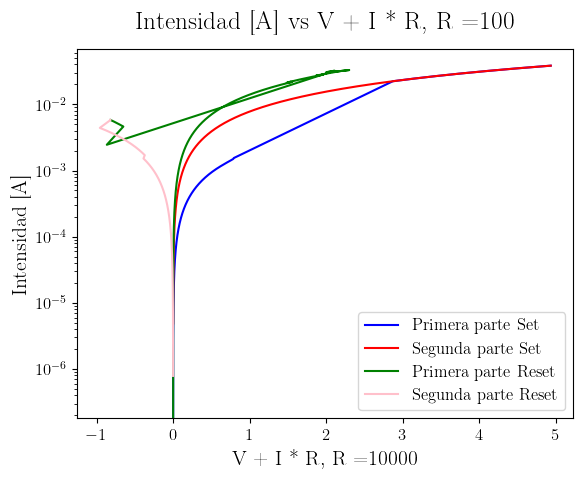

In [25]:
num_simulation = 20
xlabel = 'Voltaje [V]'
ylabel = 'Intensidad [A]'


try:
    results_path = 'C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/' + f'simulation_{num_simulation}/'
    set_simulation_path = results_path + 'set/'
    reset_simulation_path = results_path + 'reset/'
    
    data_path_pp_set = set_simulation_path + f'resultados_pp_set_{num_simulation}.csv'
    data_path_sp_set = set_simulation_path + f'resultados_sp_set_{num_simulation}.csv'
    data_path_pp_reset = reset_simulation_path + f'resultados_pp_reset_{num_simulation}.csv'
    data_path_sp_reset = reset_simulation_path + f'resultados_sp_reset_{num_simulation}.csv'
    
    df_pset = pd.read_csv(data_path_pp_set, dtype=float)
    df_sset = pd.read_csv(data_path_sp_set, dtype=float)
    df_preset = pd.read_csv(data_path_pp_reset, dtype=float)
    df_sreset = pd.read_csv(data_path_sp_reset, dtype=float)
    
except FileNotFoundError as FileNotFound_Exception:
    print("Error en la lectura de los datos de la simulación", num_simulation)
    print(f"FileNotFoundError: {FileNotFound_Exception}\n")

# Leo los datos y de cada simulacion que me interesa representar
y_ps = np.array(df_pset[ylabel])
y_ss = np.array(df_sset[ylabel])
y_pr = np.array(df_preset[ylabel])
y_sr = np.array(df_sreset[ylabel])

x_ps = np.array(df_pset[xlabel])
x_ss = np.array(df_sset[xlabel])
x_pr = np.array(df_preset[xlabel])
x_sr = np.array(df_sreset[xlabel])

resitencia = 100

i_modificada_ps = np.array(df_pset[ylabel])*resitencia + x_ps
i_modificada_ss = np.array(df_sset[ylabel])*resitencia + x_ss
i_modificada_pr = np.array(df_preset[ylabel])*resitencia + x_pr
i_modificada_sr = np.array(df_sreset[ylabel])*resitencia + x_sr


# Represento los datos
fig, axes = plt.subplots()
axes.set_xlabel('V + I * R, R =10000')
axes.set_ylabel(ylabel)

# Pongo escala logaritmica en el eje Y
axes.set_yscale('log')

global_tittle = ylabel + ' vs ' + 'V + I * R, R =100'

axes.set_title(global_tittle, fontsize=18, pad=15)

# Represento los datos del ciclo completo
axes.plot(i_modificada_ps, y_ps, color='blue', label='Primera parte Set')
axes.plot(i_modificada_ss, y_ss, color='red', label='Segunda parte Set')
axes.plot(i_modificada_pr, y_pr, color='green', label='Primera parte Reset')
axes.plot(i_modificada_sr, y_sr, color='pink', label='Segunda parte Reset')

plt.legend()